## Risikocontrolling

### Bestimmung des Parameters Probability of Default (PD) mithilfe der logistischen Regression in Python

##### In diesem Projekt geht es um die Anwendung der logistischen Regression im Risikocontrolling, um damit die Kreditausfallwahrscheinlichkeiten für Kreditnehmer zu bestimmen. 

##### Die logistische Regression ist ein Verfahren aus der Statistik und dem Machine Learning, mit dem man Wahrscheinlichkeiten für Ja/Nein-Entscheidungen berechnet. (Dabei ist meistens Ja = 1 und Nein = 0.) Der Vorgang sieht folgendermaßen aus:

##### 1. Ausgangspunkt: Daten und Ziel

##### Man hat eine Menge an Trainingsdaten über die Eingaben (Features) x_1,...,x_n
##### z. B. Alter, Einkommen, Klickanzahl,...

##### und einen Zielwert (Label) y
##### z. B. „0 = hat nicht gekauft“, „1 = hat gekauft“.

##### Die Aufgabe ist:
##### Aus den x-Werten soll eine Wahrscheinlichkeit für „1“ entstehen.

##### 2. Lineare Kombination (der erste Schritt)

##### Zuerst berechnet das Modell eine ganz normale lineare Funktion:
##### z = w_1*x_1 + ...+ w_n*x_n + b, mit

##### w_i = Gewichte (werden gelernt)
##### b = Bias (Verschiebung)
##### z = Rohwert (kann jede Zahl sein)

##### (Das ist noch keine Wahrscheinlichkeit, nur ein „Score“.)

##### 3. Umwandlung in Wahrscheinlichkeit (Sigmoid-Funktion)

##### Der rohe Wert z wird durch die logistische Funktion (Sigmoid) geschickt:

##### σ(z)= 1/(1+e^{-z}).

##### Diese Funktion macht Folgendes:

##### große negative Zahlen → nahe 0
##### große positive Zahlen → nahe 1
##### 0 → genau 0,5

##### Ergebnis:

##### \hat{y}=σ(z)

##### = Wahrscheinlichkeit für Klasse 1

##### 4. Vorhersage

##### Jetzt hat man:

##### \hat{y}= Wahrscheinlichkeit

##### Dann entscheidet man oft:

##### wenn \hat{y}≥0,5 → Klasse 1
##### wenn \hat{y}<0,5 → Klasse 0

##### (Diese Grenze 0,5 ist frei wählbar.

##### Die verwendeten Daten sind synthetisch erzeugt und dienen nur der Demonstration der Methode. In der Realität können die Verteilungen und Zusammenhänge der Variablen abweichen. 

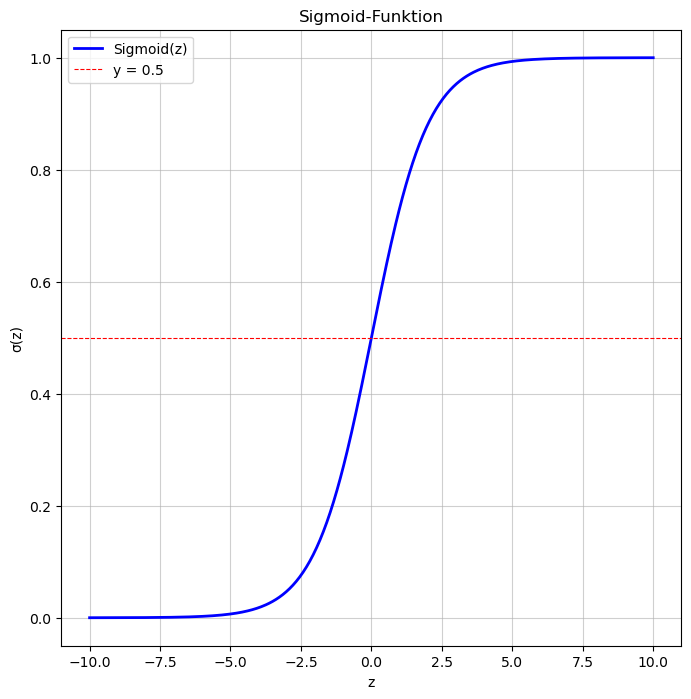

In [1]:
import matplotlib.pyplot as plt # Python-Paket, um Grafiken zu visualisieren
import numpy as np # Pytohon-Paket, um mathematische Formeln anzugeben

# Hier gebe ich die Sigmoid-Funktion an
def σ(z):
    return 1/(1+np.exp(-z))

# Hier bestimmte ich das Koordinatensystem
z = np.linspace(-10,10,500) # erzeugt den z-Achsenbereich von -10 bis 10 mit (10-(-10))/(500-1) = 20/499 Schrittweite
y = σ(z)

plt.figure(figsize=(8,8)) # legt Breite und Höhe des Koordinatensystem fest
plt.plot(z, y, label='Sigmoid(z)', color='blue', linewidth=2) # zeichnet z- und y-Achse ein mit Überschrift
plt.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='y = 0.5') # zeigt die Grenze 0,5 gestrichelt an

plt.title('Sigmoid-Funktion') # Titel
plt.xlabel('z') # Name der z-Achse
plt.ylabel('σ(z)') # Name der y-Achse
plt.legend() # zeigt Legende an
plt.grid(True, alpha=0.6) # zeigt Gitter an mit Weite 0,6
plt.show() # zeigt Grafik an

##### Wir brauchen zunächst die nötigen Python-Biblliotheken:

In [2]:
import pandas as pd # Python-Paket, um eine Tabelle zu erzeugen

from sklearn.model_selection import train_test_split # Die Daten werden in Trainings- und Testdaten aufgeteilt.
from sklearn.linear_model import LogisticRegression # Verwendung der Sigmoid-Funktion.
from sklearn.preprocessing import StandardScaler # skaliert jeden Wert hierduch: (x-\mu)/\sigma

from sklearn.metrics import log_loss # Darstellung der Funktion erfolgt in nächster Zelle

import warnings # Warnungen werden unterdrückt
warnings.filterwarnings('ignore') # Zeige keine Warnungen mehr an.

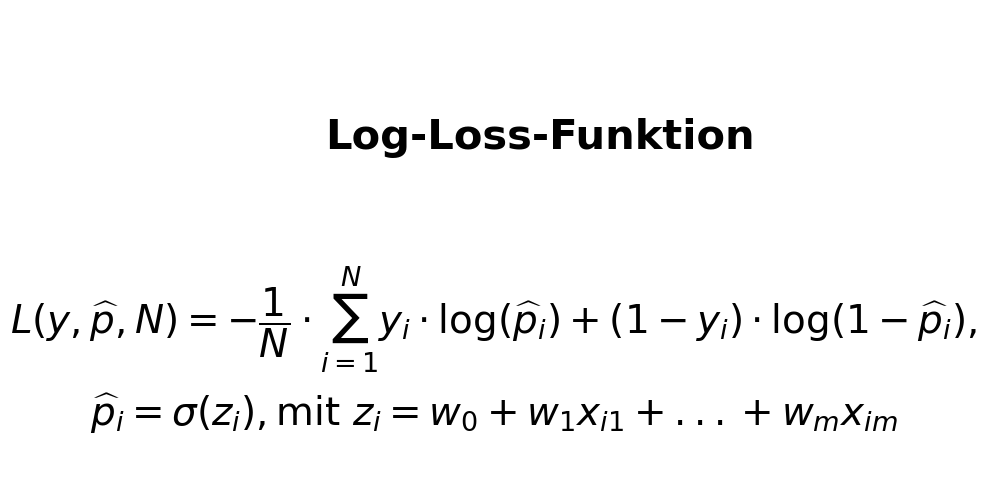

In [3]:
# Kurze Darstellung der Log_Loss-Funktion (zur Messung der geschätzten Wahrscheinlichkeiten mit den tatsächlichen Zielwerten)
plt.figure(figsize=(6, 6))
plt.text(0.6, 0.7, 'Log-Loss-Funktion', fontsize=30, ha='center', weight='bold') # platziert die Überschrift ganz oben fett
plt.text(0.5, 0.3, r'$L(y,\widehat{p},N) = -\dfrac{1}{N} \cdot \sum_{i=1}^N y_i \cdot \text{log}(\widehat{p}_i) + (1-y_i) \cdot \text{log}(1-\widehat{p}_i),$', fontsize=28, ha='center')
plt.text(0.5, 0.1, r'$\widehat{p}_i = \sigma(z_i), \text{mit} \ z_i = w_0 + w_1 x_{i1} + ... + w_m x_{im}$', fontsize=28, ha='center')
# gibt die Log_Loss-Funktion an
plt.axis('off')
plt.show()

### Beschreibung der Parameter:
#### y = (y_1,...,y_N): Zielvektor mit tatsächlichen Zielwerten
#### \widehat{p} = (\widehat{p}_1,...,\widehat{p}_N): Wahrscheinlichkeitsvektor mit geschätzten Zielwerten \widehat{y}_i
#### N = Anzahl Zielwerte

### Ziel ist es, die Log-Loss-Funktion möglichst minimal zu halten. Je niedriger die Log-Loss-Funktion, desto mehr stimmen unsere geschätzten Zielwerte mit den tatsächlichen Zielwerten überein.

##### Nun erzeugen wir ein eigenes Dataset über die Kreditausfälle.

In [4]:
np.random.seed(42)
# legt den "Startwert" (Seed) für den Zufallszahlengenerator. Dadurch werden "zufällige" Zahlen bei jedem Durchlauf exakt gleich.
df = pd.DataFrame({
    "age": np.random.randint(18, 61, 1000),
    "income": np.random.randint(1500, 12000, 1000),
    "loan_amount": np.random.randint(500, 1000000, 1000),
    "credit_score": np.clip(np.random.normal(loc=650, scale=100, size=1000),300, 850).astype(int), # np.clip(..., 300, 850): begrenzt Werte auf gültigen Bereich.
    "employment_length": np.round(np.random.uniform(0, 40, 1000), 2),
    "DTI": np.random.uniform(0, 1, 1000),
    "past_defaults": np.random.randint(0, 6, 1000),
    "default": np.random.randint(0, 2, 1000)
})

# np.random.randint: diskrete Gleichverteilung
# np.random.uniform: stetige Gleichverteilung
# np.random.normal: Normalverteilung

print(df.head()) # zeigt die ersten 5 Zeilen an

   age  income  loan_amount  credit_score  employment_length       DTI  \
0   56    6112       233101           521              17.33  0.752129   
1   46    3365       128334           557              30.97  0.905539   
2   32    7528        34584           776              34.10  0.835373   
3   60    8826       251959           603              21.67  0.196888   
4   25    7871       635429           569              30.33  0.441151   

   past_defaults  default  
0              0        0  
1              0        0  
2              4        1  
3              1        0  
4              2        0  


#### Erweiterte Erläuterung der Kreditrisiken (KR) in den einzelnen Features (qualitative Einschätzung der Risikowirkung, die in der Tabelle nicht vollständig sichtbar ist):


##### 1. Alter (Age) ↓ => KR ↑ und vice versa, da jüngere Kreditnehmer oft weniger stabile Einkünfte haben. (Bei älteren Kreditnehmern besteht jedoch eventuell ein Rentenrisiko, doch dies wird aus einfachen Gründen nicht mit berücksichtigt.)
##### 2. Einkommen (income, monatlich) beeinflusst das Kreditrisiko nicht bedingt. Hat beispielsweise ein Kreditnehmer mindestens Schulden in Höhe seines Einkommens, wirkt dies negativ auf sein Kreditrisiko und umgekehrt.
##### 3. Kreditsumme (loan_amount) ist hierbei abhängig vom individuellen Einkommen, was bedeutet, dass nicht unbedingt eine hohe Summe an Kredit zu einem höheren Kreditrisiko führt.
##### 4. Kreditwürdigkeit (credit_score) (numerisch bewertet): Hier beziehen wir uns auf die FICO-Scores (300 bis 850) mit:
##### 300–579 → sehr schlecht (hohes Ausfallrisiko)
##### 580–669 → mittel / „subprime“
##### 670–739 → gut
##### 740–799 → sehr gut
##### 800–850 → exzellent.
##### 5. Arbeitsdauer (employment_length, in Jahren) ↓ => KR ↑ und vice versa, da etwa lange Arbeitsbeschäftigungen zu stabilen Einkommensquellen führen und umgekehrt.
##### 6. DTI (Debt-to-Income Ratio) mit Werten aus [0,1]: Das ist das monatliche Verhältnis von Schulden zu Einkommen. Es misst die finanzielle Belastung direkt. Hierbei steht 0 für keine Schulden und 1 für monatliche Schulden = monatliches Einkommen.
##### 7. Vergangene Schulden (past_defaults): Ob jemand früher schon Kredite nicht zurückgezahlt hat. 

##### Wir bestimmen nun die Feature-Matrix X und den Zielvektor y. Die Feature-Matrix X beinhaltet alle Merkmale außerhalb der letzten Spalte und der Zielvektor y ist die Spalte "default" mit Werten 0 und 1. Um nun die Kreditausfallwahrscheinlichkeit PD zu simulieren, werden wir mit der Matrix X schätzungsweise die Zielwerte \widehat{y}_i bestimmen und sie mit den tatsächlichen Zielwerten y_i vergleichen.

In [5]:
X = df.drop("default", axis=1) # axis=1: Spaltenbezeichnung
y = df["default"]

##### Es ist außerdem üblich, den Datensatz zu standardisieren oder zu normalisieren, damit alle Features auf derselben Skala liegen. Dies hilft dem Modell, schneller zu lernen und kann die Modellleistung verbessern. Dafür kann die Funktion StandardScaler aus der Scikit-Learn Bibliothek verwendet werden.

In [6]:
X_norm = StandardScaler().fit(X).transform(X)
# .fit(X) bedeutet hier, dass der StandardScaler intern nebenbei die Mittelwerte \mu und Standardabweichungen \sigma berechnet mithilfe den Werten von X
# .transform(X) bedeutet hier, dass nun die Werte von X mit \mu und \sigma transformiert werden
X_norm

array([[ 1.37788340e+00, -2.15205760e-01, -8.91472550e-01, ...,
        -2.29016822e-01,  9.12692903e-01, -1.44596046e+00],
       [ 5.66695716e-01, -1.11487677e+00, -1.25484249e+00, ...,
         9.52795305e-01,  1.44922264e+00, -1.44596046e+00],
       [-5.68967042e-01,  2.48548936e-01, -1.58000148e+00, ...,
         1.22398826e+00,  1.20382614e+00,  9.20586940e-01],
       ...,
       [-1.13566276e-03,  3.35994208e-01, -1.41444960e+00, ...,
        -1.29039501e+00, -3.43624785e-01,  9.20586940e-01],
       [-1.62351103e+00, -1.48721153e-01,  6.52025095e-01, ...,
        -1.07465365e+00, -8.12964208e-01,  3.28950089e-01],
       [-9.74560884e-01, -1.37459250e+00, -7.41958376e-01, ...,
        -1.38907979e-01, -5.03513958e-01,  9.20586940e-01]])

##### Nun trennen wir den Datensatz. Wir verwenden hierbei 20% der Daten als Testdaten.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42 # alle erzeugten Größen bleiben exakt gleich
)

##### Jetzt können wir hierauf die logistische Regression anwenden. Standardmäßig wird hierfür die Grenze 0,5 gewählt.

In [8]:
LR = LogisticRegression().fit(X_train, y_train) # Hier werden die Gewichte w_i bestimmt durch L(y,\widehat{p},N) -> min!_{w_i}
yhat = LR.predict(X_test) # Die Gewichte werden jeweils in z_i eingesetzt, dann in die Sigmoid-Funktion zur Bestimmung der geschätzten Wahrscheinlichkeit. Je nach dem, ob die Wahrscheinlichkeit die Grenze 0,5 überschreitet. 
print('yhat[:10]=\n', yhat[:10]) # die ersten 10 Werte angeben.
yhat_prob = LR.predict_proba(X_test)
yhat_prob[:10] # [ P(y=0), P(y=1) ]

yhat[:10]=
 [1 1 1 1 0 1 1 1 0 1]


array([[0.42741591, 0.57258409],
       [0.47664764, 0.52335236],
       [0.39800239, 0.60199761],
       [0.43149808, 0.56850192],
       [0.51651675, 0.48348325],
       [0.49254591, 0.50745409],
       [0.48476123, 0.51523877],
       [0.4968269 , 0.5031731 ],
       [0.52033322, 0.47966678],
       [0.49437657, 0.50562343]])

##### yhat liefert uns die vorhergesagten default-Werte, die sich anhand des arrays von yhat_prob erklären lassen.

#### Hat eine Bank nun beispielsweise neue Kundendaten erhalten, kann diese Bank direkt mit der logistischen Regression den Wert des Kreditausfalls schätzungsweise bestimmen:


In [9]:
neuer_Kreditnehmer = [[21, 2100, 3500, 556, 39.33, 0.752119, 0]]
print('Ausfall=\n', LR.predict(neuer_Kreditnehmer))
print('Ausfallwahrscheinlichkeit=\n', LR.predict_proba(neuer_Kreditnehmer)[0,1])

Ausfall=
 [1]
Ausfallwahrscheinlichkeit=
 0.6399648684460587


#### Beurteilung

##### Es ist nun sinnvoll, die Leistung des Modells bei der Vorhersage der Zielvariable zu bewerten. Dafür berechnen wir den Log-Loss-Wert.

#### Log-Loss

##### Der Log-Loss (logarithmischer Verlust), auch als Binary Cross-Entropy Loss bekannt, ist eine Funktion, die einen Verlustwert basierend auf den klassenspezifischen vorhergesagten Wahrscheinlichkeiten und den tatsächlichen Klassenlabels berechnet. Je niedriger der Log-Loss-Wert ist, desto besser wird das Modell bewertet.

In [10]:
log_loss(y_test, yhat_prob)

0.6969057608052036

### Fazit

##### Der berechnete Log-Loss-Wert von 0.6969 ist nicht besonders gut, da er nahe am Wert eines zufälligen Modells liegt. Das bedeutet, dass das Modell aktuell kaum besser als reines Raten ist.

Allerdings liegt dieses Ergebnis größtenteils daran, dass die verwendeten Daten synthetisch erzeugt wurden. Dadurch besteht kein echter, realistischer Zusammenhang zwischen den Features und der Zielvariable, sodass das Modell keine sinnvollen Muster lernen kann. In einem realen Datensatz mit echten Abhängigkeiten zwischen den Variablen wäre die Modellleistung deutlich besser.

# Einsatz von echter Datenbank

In [11]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
print(df.shape)
df.head()

# Hier wird auf den Datensatz des Links [https://www.openml.org/search?type=data&sort=runs&status=active&tags.tag=Data-Science&id=31] eingegangen

(1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### Herangehensweise:
#### Der nächste Schritt wäre zunächst, alle kategorialen Variablen zu numerischen Variablen zu transformieren (Etwa mithilfe der Funktion OneHotEncoder).
#### Dann kann man wie zuvor üblich mit der Datenaufteilung beginnen und die logistische Regression auf die neue Datentabelle anwenden.
#### Demnach erhält man eine deutlich bessere Modellleistung.

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trennung in Features (X) und Zielvariable (y)
X = df.drop(columns=['class'])
y = df['class']

# 1. Automatisch kategoriale und numerische Spalten identifizieren, dabei Spaltennamen in normale Python-Listen umwandeln
categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Kategoriale Spalten ({len(categorical_cols)}): {categorical_cols}\n")

# 2. ColumnTransformer definieren
# 'sparse_output=False' sorgt dafür, dass wir ein normales NumPy-Array (keine Sparse-Matrix) zurückbekommen
# 'remainder="passthrough"' stellt sicher, dass die numerischen Spalten nicht gelöscht werden
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
# 'cat': Eigenname
# handle_unknown="ignore": 
# Wenn bei einem neuen Kreditnehmer eine Kategorie auftaucht, die das Modell noch nie gesehen hat, stürzt der Code nicht ab, sondern ignoriert sie einfach (setzt alle neuen Spalten für diesen Eintrag auf 0).

# 3. Transformation anwenden
X_transformed = preprocessor.fit_transform(X)

# 4. Die neuen Spaltennamen aus dem Preprocessor herbeirufen
# (.get_feature_names_out() generiert automatisch alle Namen für die One-Hot-Spalten und die restlichen Spalten)
neue_spaltennamen = preprocessor.get_feature_names_out()

# 5. Das Array in einen Pandas DataFrame umwandeln
X_transformed_df = pd.DataFrame(X_transformed, columns=neue_spaltennamen)

# Neue Datentabelle
print(X_transformed_df.head())

Kategoriale Spalten (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

   cat__checking_status_0<=X<200  cat__checking_status_<0  \
0                            0.0                      1.0   
1                            1.0                      0.0   
2                            0.0                      0.0   
3                            0.0                      1.0   
4                            0.0                      1.0   

   cat__checking_status_>=200  cat__checking_status_no checking  \
0                         0.0                               0.0   
1                         0.0                               0.0   
2                         0.0                               1.0   
3                         0.0                               0.0   
4                         0.0                           

In [13]:
X_norm = StandardScaler().fit(X_transformed).transform(X_transformed)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42 # alle erzeugten Größen bleiben exakt gleich
)
LR = LogisticRegression().fit(X_train, y_train) # Hier werden die Gewichte w_i bestimmt durch L(y,\widehat{p},N) -> min!_{w_i}
yhat = LR.predict(X_test) # Die Gewichte werden jeweils in z_i eingesetzt, dann in die Sigmoid-Funktion zur Bestimmung der geschätzten Wahrscheinlichkeit. Je nach dem, ob die Wahrscheinlichkeit die Grenze 0,5 überschreitet. 
print('yhat[:10]=\n', yhat[:10]) # die ersten 10 Werte angeben.
yhat_prob = LR.predict_proba(X_test)
yhat_prob[:10] # [ P(y=0), P(y=1) ]

yhat[:10]=
 ['good' 'bad' 'bad' 'good' 'good' 'good' 'good' 'bad' 'good' 'good']


array([[0.42127016, 0.57872984],
       [0.55516696, 0.44483304],
       [0.71230589, 0.28769411],
       [0.32684015, 0.67315985],
       [0.03452576, 0.96547424],
       [0.43990854, 0.56009146],
       [0.04428919, 0.95571081],
       [0.56442483, 0.43557517],
       [0.02718473, 0.97281527],
       [0.04154993, 0.95845007]])

In [14]:
log_loss(y_test, yhat_prob)

0.46213254038862106

### Fazit

#### Der Wert 0.4621 ist deutlich besser als der vorherige Wert 0.6969 unter Anwendung der künstlich erzeugten Datenbank. Für das weitere Vorgehen ist nun entscheidend, wie man das Modell optimieren kann, um einen noch niedrigeren Wert zu erhalten, was die Schätzung erheblich verbessert.